# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## $$ \textbf{Primeira Avaliação - 14 de agosto de 2024}$$

## Nome:



In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

### Questão 1:  Considere o sinal x(t) mostrado na figura abaixo:

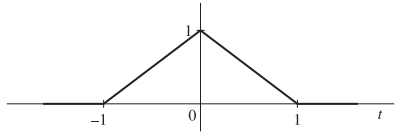

(a) Determine e cuidadosamente rascunhe $v(t)=3 x(-(1 / 2)(t+1))$

(b) Determine a energia e potência de $v(t)$.

(c) Determine e cuidadosamente rascunhe a porção par de $v(t), v_e(t)$.

(d) Seja $a=-3$ e $b=-2$, rascunhe $v(a t+$ b), $v(a t)+b, a v(t+b)$ e $a v(t)+b$.

#### Solução:

Incialmente, vamos escrever o sinal no sympy, utilizando a função *Piecewise*

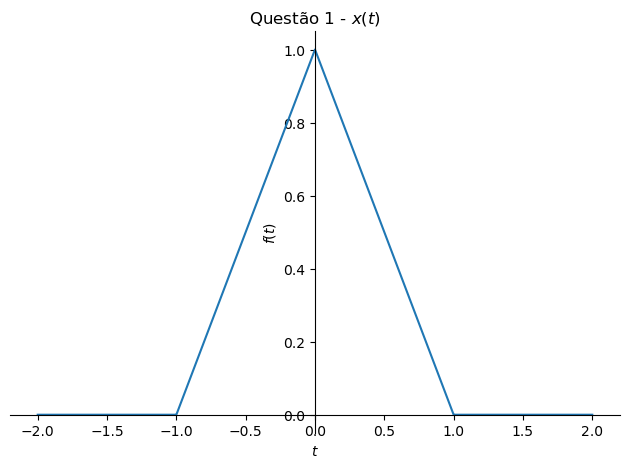

In [2]:
t = symbols('t')
x = sym.Piecewise((t + 1, (-1 <= t) & (t <=0)), (-t + 1, (0 <= t) & (t <=1)), (0, True))
sym.plot(x, (t, -2, 2), title='Questão 1 - $x(t)$')


**a)** Agora, basta usar a função *subs* para alterar o argumento e multiplicar o sinal por $3$,

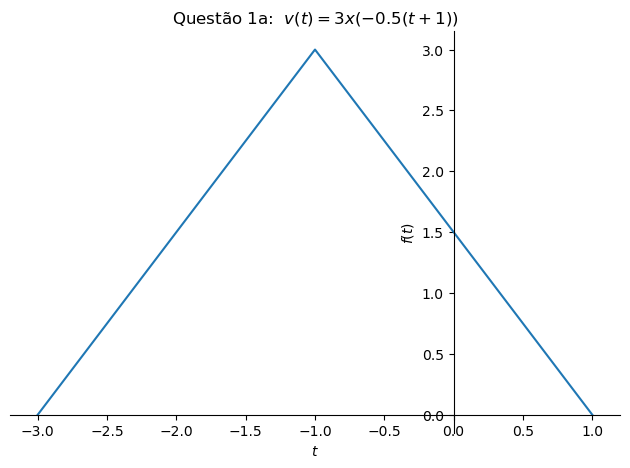

In [3]:
v = 3*x.subs(t,-0.5*(t+1))
sym.plot(v, (t, -3, 1), title='Questão 1a:  $v(t) = 3x(-0.5(t+1))$')


**b)** O sinal $v(t)$ é, notoriamente um sinal de energia. Logo, podemos inferir que sua portência é nula, isto é
$$
P_v = 0.
$$
Por sua vez, a energia é dada por

In [5]:
Exa = integrate(v**2,(t,-3,1))

display(Math('E_v = ' + latex(round(Exa,2))))

12.0000000000000

**c)** A parte par $v_e(t)$ é dada por
$$
v_e = \frac{1}{2} \left(v(t) + v(-t)  \right).
$$
Temos, portanto

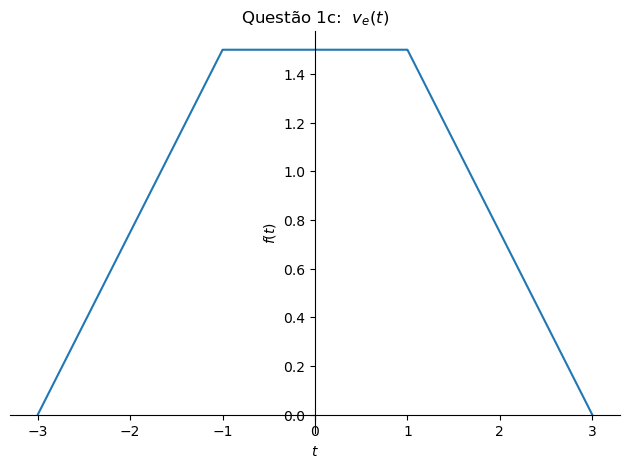

In [48]:
ve = 0.5*(v + v.subs(t,-t))
sym.plot(ve, (t, -3, 3), title='Questão 1c:  $v_e(t)$')


**(d)** Seja $a=-3$ e $b=-2$, rascunhe $v(a t+$ b), $v(a t)+b, a v(t+b)$ e $a v(t)+b$.

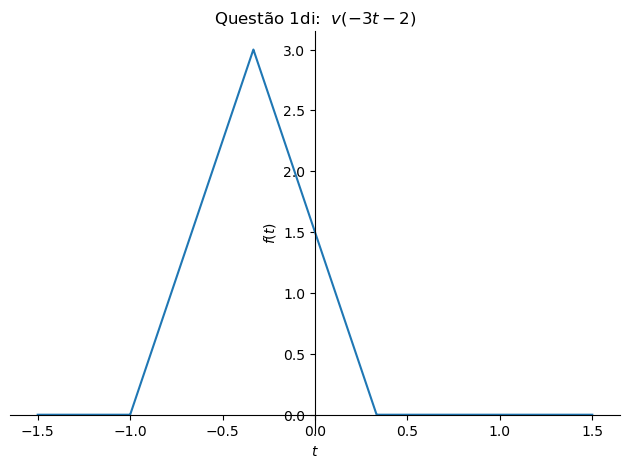

In [51]:
vd1 = v.subs(t,-3*t - 2)
sym.plot(vd1, (t, -1.5, 1.5), title='Questão 1di:  $v(-3t - 2)$')

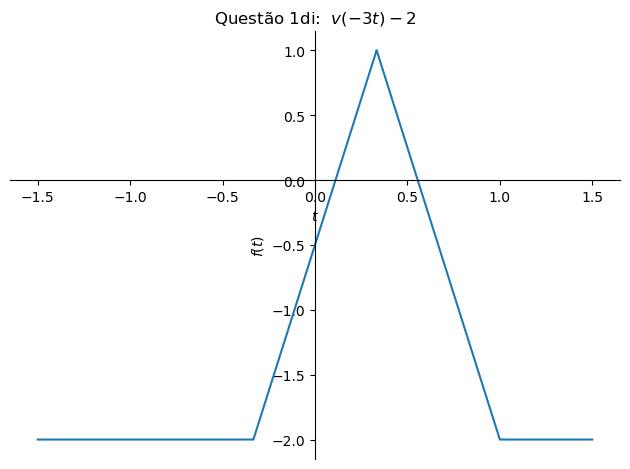

In [52]:
vd2 = v.subs(t,-3*t)
sym.plot(vd2 - 2, (t, -1.5, 1.5), title='Questão 1di:  $v(-3t) - 2$')

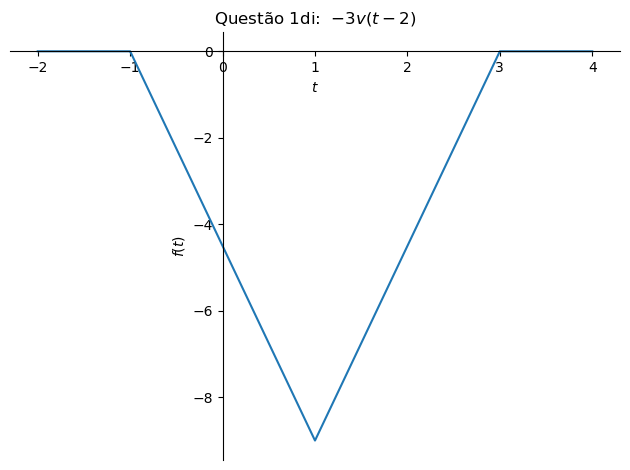

In [62]:
vd3 = -3*v.subs(t,t-2)
sym.plot(vd3, (t, -2, 4), title='Questão 1di:  $-3v(t - 2) $')

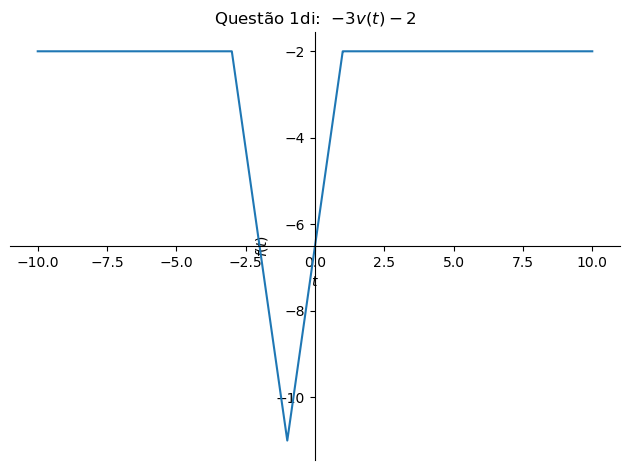

In [59]:
sym.plot(-3*v - 2, (t, -10, 10), title='Questão 1di:  $-3v(t) - 2 $')

### Questão 2: Simplifique as seguintes expressões

(a) $\left(\frac{\operatorname{sen}\left[\frac{\pi}{2}(t-2)\right]}{t^2+4}\right) \delta(1-t)$

(b) $\left(\frac{1}{j \omega+2}\right) \delta(\omega+3)$

(c) $\int_{-\infty}^{\infty} \delta(2 t-3) \operatorname{sen} \pi t d t$

(d) $\int_{-\infty}^{\infty} e^{(x-1)} \cos \left[\frac{\pi}{2}(x-5)\right] \delta(x-3) d x$

#### Solução:

- (a) $\left(\frac{\operatorname{sen}\left[\frac{\pi}{2}(t-2)\right]}{t^2+4}\right) \delta(1-t) = \left(\frac{\operatorname{sen}(-\pi/2)}{5}\right) \delta(1-t) = -\frac{1}{5} \delta(1-t).$

- (b) $\left(\frac{1}{j \omega+2}\right) \delta(\omega+3) = \left(\frac{1}{-3j + 2}\right) \delta(\omega+3) = \frac{3j + 2}{13} \delta(\omega+3)$

- (c) $\int_{-\infty}^{\infty} \delta(2 t-3) \operatorname{sen} \pi t d t = \frac{\operatorname{sen} 3 \pi/2}{2} = -1/2$

In [75]:
t = symbols('t')
integrate(DiracDelta(2*t-3)*sin(pi*t), (t, -oo,oo))

-1/2


- (d) $\int_{-\infty}^{\infty} e^{(x-1)} \cos \left[\frac{\pi}{2}(x-5)\right] \delta(x-3) d x$

In [76]:
integrate(DiracDelta(t-3)*cos(pi*(t - 5)/2)*exp(t - 1), (t, -oo,oo))

-exp(2)

### Questão 3: Um sistema em tempo contínuo é dado por $y(t)=0,5 \int_{-\infty}^{\infty} x(\tau)[\delta(t- \tau)+\delta(t+\tau)] d \tau $

(a) O sistema é estável BIBO? Justifique sua resposta.

(b) O sistema é linear? Justifique sua resposta.

(c) O sistema é causal? Justifique sua resposta. 
 
(d) O sistema é invariante no tempo? Justifique sua resposta.

#### Solução

$$y(t)=0,5 \int_{-\infty}^{\infty} x(\tau)[\delta(t- \tau)+\delta(t+\tau)] d \tau  = 0,5(x(t) + x(-t))$$

Ou seja, o sinal de saída é a parte par do sinal de entrada

- (a) O sistema é estável Bibo, pois dado um sinal limitado, sua componente par é também um sinal limitado.
De fato, considerando
$$
||x(t)|| < M_x,
$$
temos
$$
\begin{aligned}
||y(t)|| = 0,5||x(t) + x(-t)|| &\leq 0,5\left(||x(t)|| + ||x(-t)|| \right) \\
&\leq 0,5\left(M_x + M_x \right) = M_x.
\end{aligned}
$$

 - (b) Sejam $y_1(t)=0,5\left(x_1(t)+x_1(-t)\right)$ e $y_2(t)=0,5\left(x_2(t)+x_2(-t)\right)$ . 
 
 Aplicar $a x_1(t)+b x_2(t)$ ao sistema produz 
 $$
 \begin{aligned}
 y(t) &= 0.5\left(a x_1(t) + b x_2(t) + a x_1(-t)+ b x_2(-t)\right) \\
  & =0,5 a\left(x_1(t)+x_1(-t)\right)+ 0,5 b\left(x_2(t)+x_2(-t)\right )\\
  & = a y_1(t)+b y_2(t)
 \end{aligned}
 $$

Assim, o sistema é linear.

 - (c) Por inspeção, fica claro que a saída do sistema para $t<0$ depende de entradas futuras. Por exemplo, no tempo $t=-1$ a saída $y(-1)=0.5(x(-1)+x(1))$ depende de um valor futuro da entrada, $x(1)$.

Não. O sistema não é causal.

 - (d) Usaremos um contraexemplo para provar que o sistema não é invariante no tempo. 
 
Seja a entrada $x(t) = cos(t)$. Como a entrada é par, sua saída e o prório sinal $y(t) = x(t)$.

Note que $cos(t - \pi/2) = sin(t).$ Assim, um atraso de $\pi/2$ implica em saída nula e não no mesmo atraso da entrada.

Portando, o sistema não é invariante no tempo.

### Questão 4: A resposta ao impulso unitário de um sistema LCIT é $h(t)=e^{-t} u(t)$. Determine a resposta do sistema $y(t)$ se a entrada $x(t)$ for

(a) $u(t)$

(b) $\operatorname{sen}(3 t) u(t)$

#### Solução:

Temos que a resposta é dada por

$$
y(t) = x(t)*h(t) = \int_{-\infty}^{\infty} x(\tau)h(t - \tau)d\tau
$$
**(a)**

In [6]:
t, tau = symbols('t tau', real = True)
integrate(Heaviside(tau)*exp(-t + tau)*Heaviside(t - tau), (tau,-oo,oo))

Piecewise((exp(-t), (t > 0) & (t < 0)), (Integral(exp(-t + tau)*Heaviside(tau)*Heaviside(t - tau), (tau, -oo, oo)), True))

In [8]:
simplify(integrate(sin(3*tau)*Heaviside(tau)*exp(- t + tau)*Heaviside(t - tau), (tau,-oo,oo)))

(exp(t)*sin(3*t) - 3*exp(t)*cos(3*t) + 3)*exp(-t)*Heaviside(t)/10